# IPL Cricket Analysis Dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [2]:
matches = pd.read_csv('ipl_match_data_2008-2023.csv')
balls = pd.read_csv('ipl_ball_by_ball_data_2008-2023.csv')

C:\Users\Onkar Swami\AppData\Local\Temp\ipykernel_11620\1876508264.py:2: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  balls = pd.read_csv('ipl_ball_by_ball_data_2008-2023.csv')


In [3]:
matches.head()

,id,date,season,event_name,match_type,match_number,city,venue,team1,team2,...,team2players,toss_winner,toss_decision,winner,result,eliminator,wonBy,margin,method,player_of_match
0,335982,18-04-2008,2007/08,Indian Premier League,T20,1,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,...,"['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Royal Challengers Bangalore,field,Kolkata Knight Riders,NaN,NaN,runs,140.0,NaN,['BB McCullum']
1,335983,19-04-2008,2007/08,Indian Premier League,T20,2,Chandigarh,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,...,"['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",Chennai Super Kings,bat,Chennai Super Kings,NaN,NaN,runs,33.0,NaN,['MEK Hussey']
2,335984,19-04-2008,2007/08,Indian Premier League,T20,3,Delhi,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,...,"['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Rajasthan Royals,bat,Delhi Daredevils,NaN,NaN,wickets,9.0,NaN,['MF Maharoof']
3,335986,20-04-2008,2007/08,Indian Premier League,T20,4,Kolkata,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,...,"['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",Deccan Chargers,bat,Kolkata Knight Riders,NaN,NaN,wickets,5.0,NaN,['DJ Hussey']
4,335985,20-04-2008,2007/08,Indian Premier League,T20,5,Mumbai,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,...,"['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",Mumbai Indians,bat,Royal Challengers Bangalore,NaN,NaN,wickets,5.0,NaN,['MV Boucher']


In [4]:
balls.head()

,id,season,venue,batting_team,bowling_team,innings,over,ball,is_super_over,batter,...,total_runs,is_wkt_delivery,player_out,wkt_type,fielders_involved,byes,legbyes,wides,noballs,penalty
0,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,1,0,SC Ganguly,...,1,0,NaN,NaN,NaN,0,1,0,0,0
1,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,2,0,BB McCullum,...,0,0,NaN,NaN,NaN,0,0,0,0,0
2,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,3,0,BB McCullum,...,1,0,NaN,NaN,NaN,0,0,1,0,0
3,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,4,0,BB McCullum,...,0,0,NaN,NaN,NaN,0,0,0,0,0
4,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,1,0,5,0,BB McCullum,...,0,0,NaN,NaN,NaN,0,0,0,0,0


## KPI 1 - Total Matches

In [5]:
total_matches = matches['id'].nunique()
print('Total IPL Matches:', total_matches)

Total IPL Matches: 1024


## KPI 2 - Highest Run Scorer

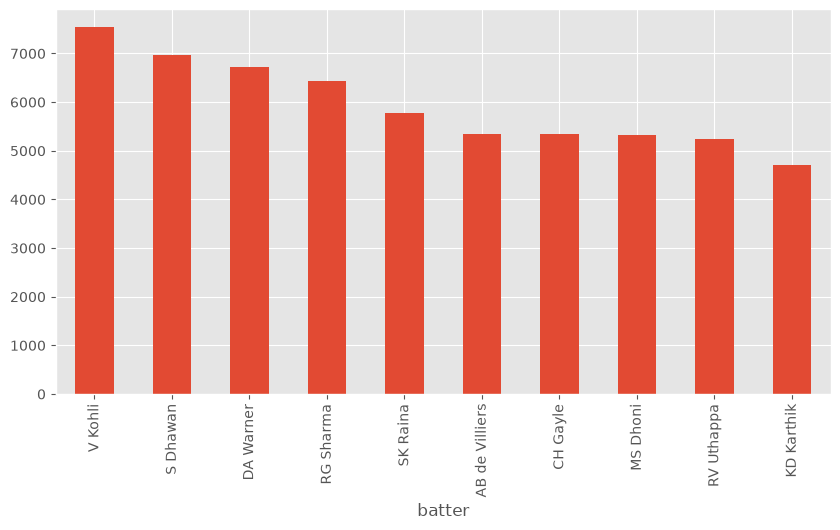

In [22]:
top_batsman = balls.groupby('batter')['total_runs'].sum().sort_values(ascending=False)
top_batsman.head(10).plot(kind='bar', figsize=(10,5))
plt.show()

## KPI 3 - Highest Wicket Taker

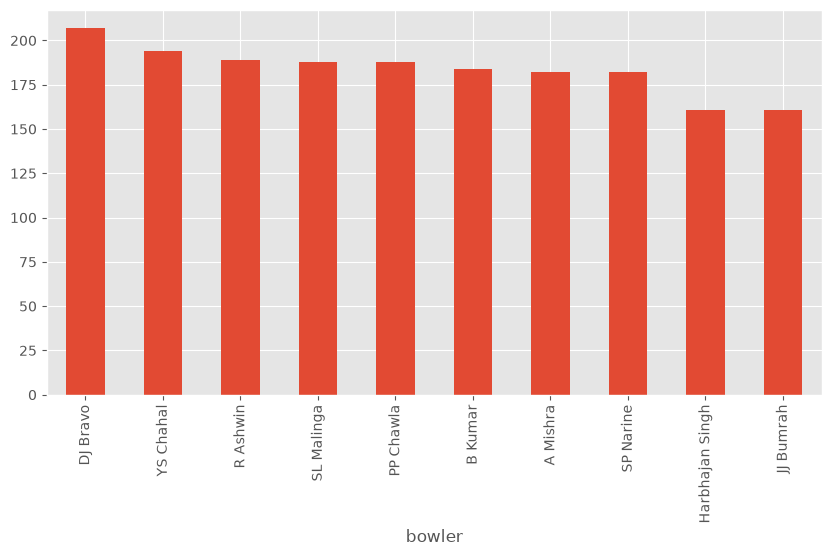

In [7]:
wickets = balls[balls['is_wkt_delivery']==1]
top_bowlers = wickets.groupby('bowler')['player_out'].count().sort_values(ascending=False)
top_bowlers.head(10).plot(kind='bar', figsize=(10,5))
plt.show()

## KPI 4 - Team Wins

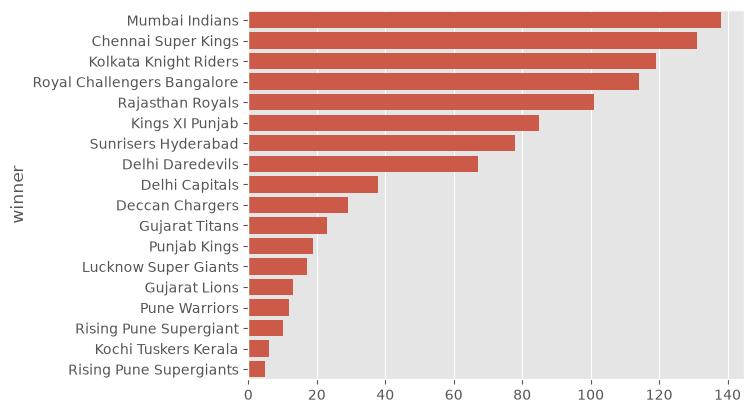

In [8]:
team_wins = matches['winner'].value_counts()
sns.barplot(x=team_wins.values, y=team_wins.index)
plt.show()

## KPI 5 - Venue Analysis

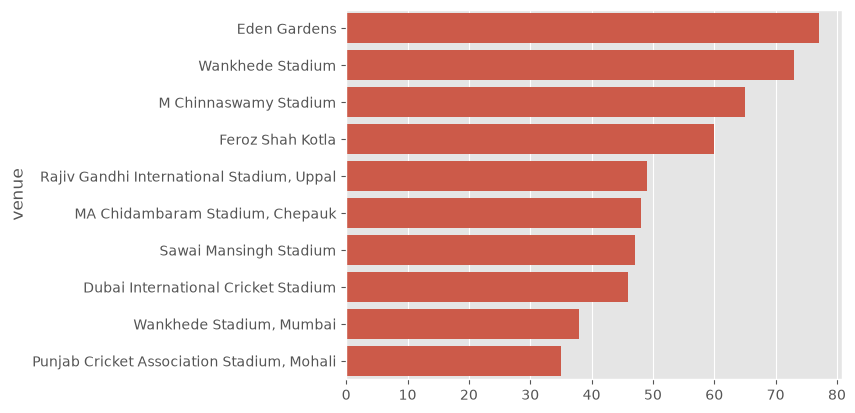

In [9]:
venue_matches = matches['venue'].value_counts().head(10)
sns.barplot(x=venue_matches.values, y=venue_matches.index)
plt.show()

## KPI 6 - Toss Impact

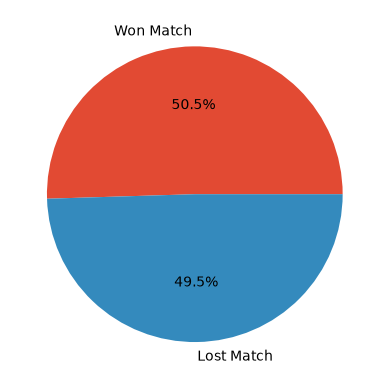

In [10]:
matches['toss_match_win']=matches['toss_winner']==matches['winner']
toss_impact=matches['toss_match_win'].value_counts()
plt.pie(toss_impact,labels=['Won Match','Lost Match'],autopct='%1.1f%%')
plt.show()

## KPI 7 - Most Player of the Match Awards

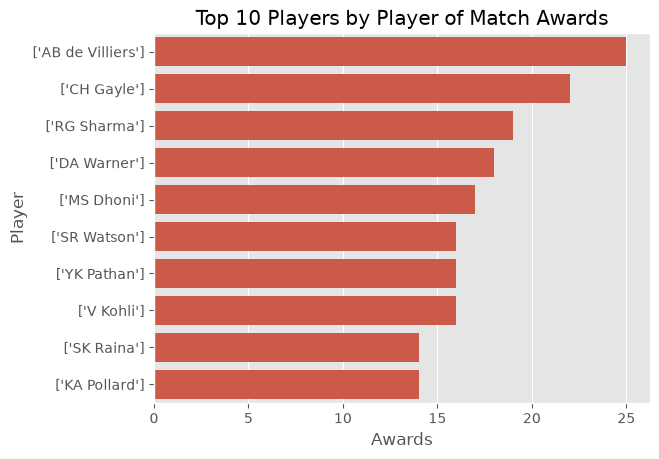

In [11]:
player_of_match = matches['player_of_match'].value_counts().head(10)
sns.barplot(x=player_of_match.values, y=player_of_match.index)
plt.title('Top 10 Players by Player of Match Awards')
plt.xlabel('Awards')
plt.ylabel('Player')
plt.show()

## KPI 8 - Highest Run Scoring Teams

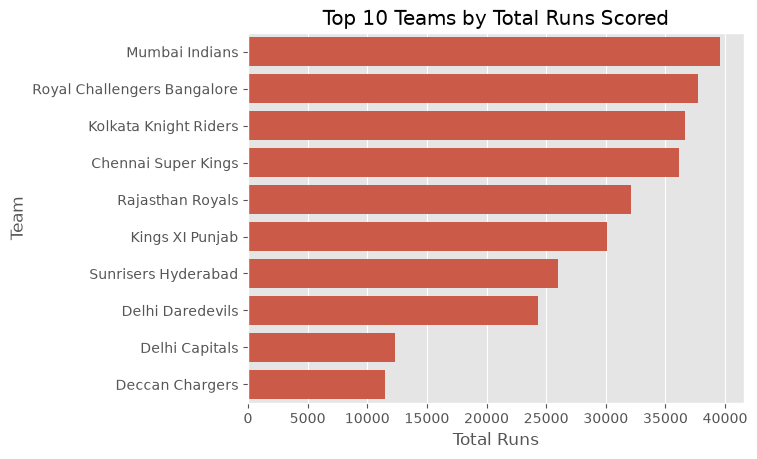

In [12]:
team_runs = balls.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=team_runs.values, y=team_runs.index)
plt.title('Top 10 Teams by Total Runs Scored')
plt.xlabel('Total Runs')
plt.ylabel('Team')
plt.show()

## KPI 9 - Most Frequent Match Cities

In [ ]:
city_counts = matches['city'].value_counts().head(10)
sns.barplot(x=city_counts.values, y=city_counts.index)
plt.title('Top 10 IPL Cities by Match Count')
plt.xlabel('Matches')
plt.ylabel('City')
plt.show()

## KPI 10 - Top Six Hitters

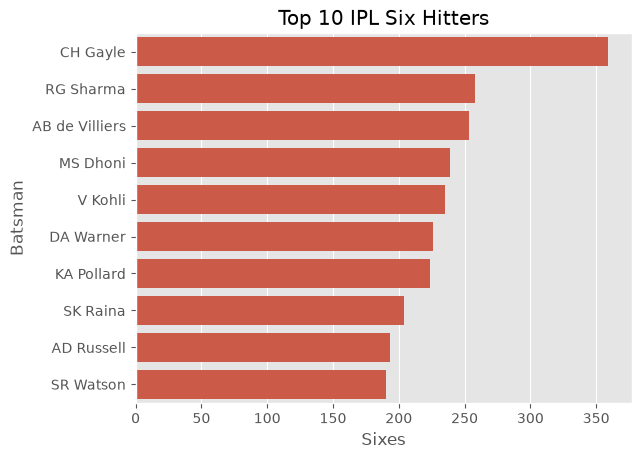

In [13]:
six_hits = balls[balls['runs_off_bat'] == 6]
top_six_batsmen = six_hits['batter'].value_counts().head(10)
sns.barplot(x=top_six_batsmen.values, y=top_six_batsmen.index)
plt.title('Top 10 IPL Six Hitters')
plt.xlabel('Sixes')
plt.ylabel('Batsman')
plt.show()

## KPI 11 - Teams with Highest Average Runs per Match

In [ ]:
team_total_runs = balls.groupby('batting_team')['total_runs'].sum()
team_matches = balls.groupby('batting_team')['id'].nunique()
team_avg_runs = (team_total_runs / team_matches).sort_values(ascending=False).head(10)
sns.barplot(x=team_avg_runs.values, y=team_avg_runs.index)
plt.title('Top 10 Teams by Average Runs per Match')
plt.xlabel('Average Runs')
plt.ylabel('Team')
plt.show()

## KPI 12 - Toss Decision Win Rate

In [ ]:
win_rate_by_decision = matches.groupby('toss_decision')['toss_match_win'].mean().sort_values(ascending=False)
win_rate_by_decision = win_rate_by_decision * 100
sns.barplot(x=win_rate_by_decision.values, y=win_rate_by_decision.index)
plt.title('IPL Toss Decision Win Rate')
plt.xlabel('Win Rate (%)')
plt.ylabel('Toss Decision')
plt.show()

## KPI 13 - Most Common Wicket Types


In [ ]:
wicket_types = wickets['wkt_type'].dropna().value_counts().head(10)
sns.barplot(x=wicket_types.values, y=wicket_types.index)
plt.title('Top 10 Wicket Types in IPL')
plt.xlabel('Wicket Count')
plt.ylabel('Wicket Type')
plt.show()


## KPI 14 - Teams by Win Percentage


In [ ]:
team_appearances = pd.concat([matches['team1'], matches['team2']])
matches_played = team_appearances.value_counts()
team_wins = matches['winner'].value_counts()
win_percentage = (team_wins / matches_played).sort_values(ascending=False).head(10)
sns.barplot(x=win_percentage.values * 100, y=win_percentage.index)
plt.title('Top 10 Teams by Win Percentage')
plt.xlabel('Win Percentage (%)')
plt.ylabel('Team')
plt.show()


## KPI 15 - Teams with Most Sixes


In [ ]:
team_sixes = balls[balls['runs_off_bat'] == 6]['batting_team'].value_counts().head(10)
sns.barplot(x=team_sixes.values, y=team_sixes.index)
plt.title('Top 10 Teams by Sixes Hit')
plt.xlabel('Sixes')
plt.ylabel('Team')
plt.show()
